# tabnet

## 1.import libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## 2.load data

In [ ]:
from preprocessing_22 import load_data_scaled

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    feature_names
) = load_data_scaled()

In [ ]:
# convert to numpy arrays
X_train = X_train.values
X_val = X_val.values
X_test = X_test.values

y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

## 3.tarin model

In [ ]:
# initialize TabNet classifier
tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax',
    seed=42
)

c:\Users\nabia\ALL_PROJECTS\ML_Project\venv311\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [ ]:
tabnet.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],
    eval_name=[
        'train',
        'validation'
    ],
    eval_metric=[
        'auc'
    ],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

epoch 0  | loss: 0.47444 | train_auc: 0.88203 | validation_auc: 0.88341 |  0:01:20s
epoch 1  | loss: 0.4039  | train_auc: 0.89315 | validation_auc: 0.89404 |  0:02:44s
epoch 2  | loss: 0.38825 | train_auc: 0.89786 | validation_auc: 0.89841 |  0:04:09s
epoch 3  | loss: 0.38083 | train_auc: 0.90441 | validation_auc: 0.90474 |  0:05:35s
epoch 4  | loss: 0.37318 | train_auc: 0.90706 | validation_auc: 0.90738 |  0:07:02s
epoch 5  | loss: 0.36726 | train_auc: 0.90887 | validation_auc: 0.90901 |  0:08:28s
epoch 6  | loss: 0.36432 | train_auc: 0.90987 | validation_auc: 0.91005 |  0:09:56s
epoch 7  | loss: 0.36209 | train_auc: 0.90959 | validation_auc: 0.9098  |  0:11:28s
epoch 8  | loss: 0.36102 | train_auc: 0.91102 | validation_auc: 0.91117 |  0:13:11s
epoch 9  | loss: 0.36212 | train_auc: 0.90529 | validation_auc: 0.90494 |  0:15:08s
epoch 10 | loss: 0.36388 | train_auc: 0.91098 | validation_auc: 0.91053 |  0:17:10s
epoch 11 | loss: 0.35971 | train_auc: 0.91206 | validation_auc: 0.91179 |  0

c:\Users\nabia\ALL_PROJECTS\ML_Project\venv311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


## 4.predictions

In [ ]:
# predict on the test set
y_pred = tabnet.predict(X_test)

y_prob = tabnet.predict_proba(X_test)[:, 1]

## 5.metrics

In [ ]:
# evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

Accuracy : 0.8420
Precision: 0.8086
Recall   : 0.7041
F1 Score : 0.7528
ROC AUC  : 0.9108


In [ ]:
# classification report
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88     80802
           1       0.81      0.70      0.75     41934

    accuracy                           0.84    122736
   macro avg       0.83      0.81      0.82    122736
weighted avg       0.84      0.84      0.84    122736



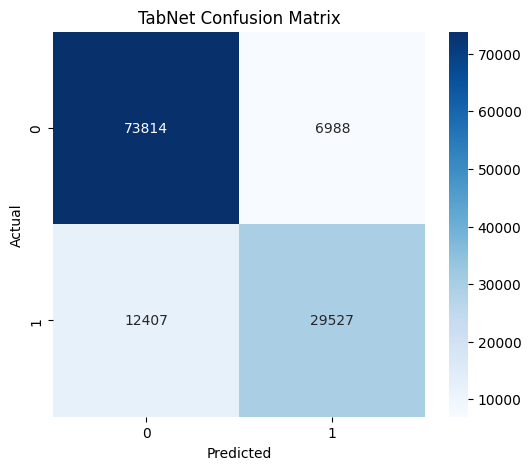

In [ ]:
# confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("TabNet Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/plots/tabnet_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)  

plt.show()

## 6.roc curve

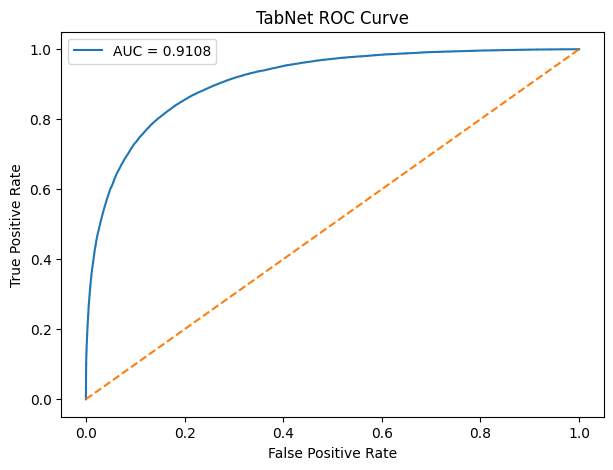

In [ ]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("TabNet ROC Curve")

plt.legend()
plt.savefig(
    "../results/plots/tabnet_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
tabnet.save_model(
    "../models/higgs_tabnet"
)

Successfully saved model at ../models/higgs_tabnet2.zip


'../models/higgs_tabnet2.zip'